# Suggestions for Notebook: `03_04_tree_based_models`

For `03_04_tree_based_models`, as requested, the focus will shift to classification tasks, specifically predicting customer churn risk using tree-based models like Random Forest and XGBoost.

**Proposed Plan for `03_04_tree_based_models`:**

1.  **Objective:** Build and evaluate classification models to predict `churn_label` using tree-based algorithms (Random Forest and XGBoost).
2.  **Data Preparation for Classification:**
    *   Identify the target variable: `churn_label`.
    *   Re-split the dataset into training and testing sets, ensuring proper stratification if churn labels are imbalanced.
    *   Consider any specific feature engineering or encoding necessary for classification, such as one-hot encoding for categorical features if not already handled.
3.  **Model Training:**
    *   **Random Forest Classifier:** Train a Random Forest model on the prepared training data.
    *   **XGBoost Classifier:** Train an XGBoost model on the prepared training data.
4.  **Model Evaluation:**
    *   Predict `churn_label` on the test set for both models.
    *   Evaluate model performance using appropriate classification metrics:
        *   Accuracy Score
        *   Precision, Recall, and F1-Score (especially important for imbalanced datasets)
        *   Confusion Matrix
        *   ROC AUC Score and ROC Curve
    *   Consider feature importance analysis for both models to understand which features drive churn prediction.
5.  **Model Comparison:** Compare the performance of Random Forest and XGBoost based on all the evaluation metrics. Discuss the strengths and weaknesses of each model in the context of predicting churn for this dataset.
6.  **Conclusion:** Summarize the findings and recommend the better-performing model for churn prediction, along with actionable insights derived from feature importance.

---

03_02's regression target was a continuous variable that supports the overall story of our project.

Here, we transition naturally to Classification by predicting **churn risk** using Random Forest and XGBoost.

* Random Forest (Bagging)
* XGBoost (Boosting)
* Hyperparameter Tuning
* Model Comparison

| Model                      | Strength                       |
| -------------------------- | ------------------------------ |
| Multiple Linear Regression | Interpretability               |
| Decision Tree              | Simple decision rules          |
| Random Forest              | Robust ensemble                |
| XGBoost                    | Highest predictive performance |


Then, conclude like:

"Although Multiple Linear Regression provides valuable interpretability, XGBoost achieved the best predictive performance and was therefore selected as the production model."

Akin to an Enterprise model selection rationale.

In [1]:
# Install nbimporter
!pip install nbimporter

# This library allows us to treat a ".ipynb" file like a Python module
import nbimporter

In [2]:
import pandas as pd
import requests
import nbimporter

pd.set_option('display.max_columns', None)

from google.colab import drive
drive.mount('/content/drive')

import sys

sys.path.append("/content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform/utils")

# Defining the URL for the Customer Features Dataset
url = "https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/gold_ml-ready_customer-features.csv"

Mounted at /content/drive


In [3]:
# Data Loading

# Importing Functions from '03_01_customer_segmentation.ipynb' using 'nbimporter'
from data_loader import load_gold_ml_dataset, load_customer_churn_data, clean_customer_churn_data

df = load_customer_churn_data(url)
df = clean_customer_churn_data(df)

df.sample(7)

✓ Successfully loaded 300 records.


,customerID,customer_value_quintile,total_transactions,lifetime_spend,avg_transaction_value,avg_unit_price,total_items,avg_items_per_transaction,unique_products,unique_franchises,payment_method_diversity,first_purchase,last_purchase,recency_days,customer_lifetime_days,avg_days_between_purchases,active_days,active_months,revenue_per_order,avg_basket_size,avg_monthly_spend,multi_franchise_customer,high_value_customer,churn_label
3,2000003,3,13,216,16.62,3,72,5.54,5,10,3,2024-05-04T15:43:27.910Z,2024-05-17T11:01:41.673Z,783,13,1.08,10,1,16.62,5.54,216,1,0,1
152,2000152,4,8,162,20.25,3,54,6.75,5,8,3,2024-05-02T09:34:57.144Z,2024-05-16T08:13:04.134Z,784,14,2.00,4,1,20.25,6.75,162,1,0,1
39,2000039,4,12,174,14.50,3,58,4.83,6,12,3,2024-05-01T00:05:11.763Z,2024-05-16T13:51:37.493Z,784,15,1.36,8,1,14.50,4.83,174,1,0,1
298,2000298,1,12,297,24.75,3,99,8.25,4,10,3,2024-05-01T21:25:35.354Z,2024-05-17T07:36:31.729Z,783,16,1.45,9,1,24.75,8.25,297,1,1,1
194,2000194,4,11,177,16.09,3,59,5.36,4,11,3,2024-05-06T01:09:44.928Z,2024-05-17T07:49:27.056Z,783,11,1.10,7,1,16.09,5.36,177,1,0,1
63,2000063,4,7,165,23.57,3,55,7.86,4,6,3,2024-05-06T05:31:44.206Z,2024-05-17T09:51:28.688Z,783,11,1.83,6,1,23.57,7.86,165,1,0,1
273,2000273,2,11,234,21.27,3,78,7.09,6,11,3,2024-05-01T08:59:31.947Z,2024-05-12T15:45:38.774Z,788,11,1.10,7,1,21.27,7.09,234,1,1,1




---

## Plan for Model Development and Comparison

This section outlines the steps for developing, evaluating, and comparing different tree-based machine learning models to predict customer lifetime spend. The goal is to identify the most suitable model for production, balancing predictive performance with interpretability.

### Steps:
1.  **Feature Preparation**: Prepare the input features (`X`) and target variable (`y`) for model training, including encoding categorical features and standardizing numerical features.
2.  **Model Selection**: Implement the following models:
    *   **Decision Tree Regressor**: As an interpretable baseline.
    *   **Random Forest Regressor (Bagging)**: An ensemble method that averages multiple decision trees to improve accuracy and reduce overfitting.
    *   **XGBoost Regressor (Boosting)**: A gradient boosting framework known for its high predictive performance.
3.  **Hyperparameter Tuning**: Optimize the XGBoost model using `GridSearchCV` to find the best hyperparameters.
4.  **Model Training and Evaluation**: Train each model on the prepared data and evaluate their performance using regression metrics such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R2) score.
5.  **Model Comparison**: Compare the performance of all models to determine the best-performing one, considering both predictive accuracy and interpretability.
6.  **Conclusion**: Provide a rationale for selecting the final production model based on the comparison results.

---

## Random Forests

## Gradient Boosting (XGBoost)

## Decision Tree

In [4]:
# XGBoost - Gradient Boosting
# Builds one Tree at a Time; each Tree focuses on Correcting the Errors of the Previous Tree
# Final Result: Weighted Sum of all Trees

from xgboost import XGBClassifier # Changed to Classifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report # Added classification metrics
from sklearn.preprocessing import StandardScaler

In [5]:
# Let's Build the Model

X = pd.concat([pd.get_dummies(df[['multi_franchise_customer']]),
               df[['avg_transaction_value', 'avg_items_per_transaction', 'avg_days_between_purchases',
               'avg_basket_size', 'avg_monthly_spend']]],
                axis = 1)
y = df['high_value_customer'].astype(int) # ! Target variable: Does Customer Churn or not?

# Standardizing the Features
sc = StandardScaler()

X = sc.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 7)

In [6]:
# Hyperparameter Tuning to Optimize the XGBoost Model

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier # Ensure XGBClassifier is used here

# Defining the Parameter Grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0] # Added colsample_bytree for tuning
}

# Performing Grid Search for Classification
grid_search = GridSearchCV(XGBClassifier(objective = 'binary:logistic', eval_metric = 'logloss', random_state = 7),
                           param_grid, cv = 3, scoring = 'roc_auc', n_jobs = -1, verbose = 1)
grid_search.fit(X_train, y_train)

# Printing the Best Parameters
print("Best Parameters:", grid_search.best_params_)

# Let's get the XGBoost Model going - Using the Optimal Parameters as Determined^
# Using the best Estimator directly from 'grid_search'
xgreg = grid_search.best_estimator_

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [7]:
# Fitting the Model

xgreg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [8]:
# Making some Predictions
y_pred = xgreg.predict(X_test)
y_proba = xgreg.predict_proba(X_test)[:, 1] # For ROC-AUC

# Evaluating the Gradient Boosting Classification Model
print("Accuracy Score:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("Precision Score:", round(precision_score(y_test, y_pred, zero_division = 0) * 100, 2), "%")
print("Recall Score:", round(recall_score(y_test, y_pred, zero_division = 0) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test, y_pred, zero_division = 0) * 100, 2), "%")
print("ROC AUC Score:", round(roc_auc_score(y_test, y_proba), 2))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division = 0))

Accuracy Score: 100.0 %
Precision Score: 100.0 %
Recall Score: 100.0 %
F1 Score: 100.0 %
ROC AUC Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        40

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



<Figure size 2400x1200 with 0 Axes>

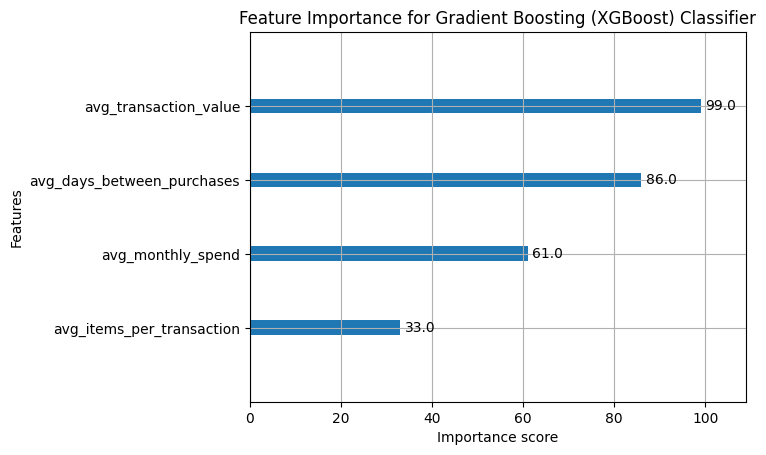

In [9]:
# Details of the Gradient Boosting XGBoost Model

import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import plot_importance

# Recreating the Feature names based on the current 'X' definition
feature_columns_for_dummies = ['multi_franchise_customer']
numerical_columns = ['avg_transaction_value', 'avg_items_per_transaction', 'avg_days_between_purchases',
                     'avg_basket_size', 'avg_monthly_spend']

# Getting the Dummy column names
dummy_feature_names = pd.get_dummies(df[feature_columns_for_dummies]).columns.tolist()

# Combining with Numerical Feature names
actual_feature_names = dummy_feature_names + numerical_columns

# Assigning the dynamically obtained Feature names to the Booster
xgreg.get_booster().feature_names = actual_feature_names

plt.figure(figsize = (24, 12))
plot_importance(xgreg, max_num_features = None)
plt.title('Feature Importance for Gradient Boosting (XGBoost) Classifier')
plt.show()

In [10]:
# Building the Random Forest Classifier and Decision Tree Classifier & Evaluating & Comparing them to the XGBoost Model too

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

models = {
    "Decision Tree Classifier": DecisionTreeClassifier(random_state = 42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators = 300, n_jobs = -1, random_state = 7),
    "Gradient Boosting (XGBoost) Classifier": xgreg
}

results = []
classification_reports = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division = 0)
    recall = recall_score(y_test, y_pred, zero_division = 0)
    f1 = f1_score(y_test, y_pred, zero_division = 0)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 'N/A'

    results.append({
        "Model": name,
        "Accuracy": round(accuracy * 100, 2),
        "Precision": round(precision * 100, 2),
        "Recall": round(recall * 100, 2),
        "F1 Score": round(f1 * 100, 2),
        "ROC AUC": round(roc_auc, 2) if isinstance(roc_auc, (int, float)) else roc_auc
    })
    classification_reports[name] = classification_report(y_test, y_pred, output_dict=True, zero_division=0)


# Let's look at & Evaluate each Model and also Compare it to Others
results_df = pd.DataFrame(results).sort_values(by = "F1 Score", ascending = False)
display(results_df)

print("\nClassification Reports:")
for name, report_dict in classification_reports.items():
    print(f"\n--- {name} ---")
    report_df = pd.DataFrame(report_dict).transpose()
    display(report_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Decision Tree Classifier,100.0,100.0,100.0,100.0,1.0
1,Random Forest Classifier,100.0,100.0,100.0,100.0,1.0
2,Gradient Boosting (XGBoost) Classifier,100.0,100.0,100.0,100.0,1.0



Classification Reports:

--- Decision Tree Classifier ---


,precision,recall,f1-score,support
0,1.0,1.0,1.0,35.0
1,1.0,1.0,1.0,40.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,75.0
weighted avg,1.0,1.0,1.0,75.0



--- Random Forest Classifier ---


,precision,recall,f1-score,support
0,1.0,1.0,1.0,35.0
1,1.0,1.0,1.0,40.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,75.0
weighted avg,1.0,1.0,1.0,75.0



--- Gradient Boosting (XGBoost) Classifier ---


,precision,recall,f1-score,support
0,1.0,1.0,1.0,35.0
1,1.0,1.0,1.0,40.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,75.0
weighted avg,1.0,1.0,1.0,75.0


In [11]:
import joblib
import os

# Define the Base path, respectively, for saving Models and Predictions
models_save_path = "/content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform/models"
preds_save_path = "/content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform/outputs"

# Creating the Directory if it does NOT exist
os.makedirs(models_save_path, exist_ok = True)
os.makedirs(preds_save_path, exist_ok = True)

# Save each model and its predictions
for name, model in models.items():
    # Sanitize model name for filename
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')

    # Save the model
    model_filename = os.path.join(models_save_path, f"{safe_name}_model.joblib")
    joblib.dump(model, model_filename)
    print(f"Saved {name} model to {model_filename}")

    # Make predictions for saving
    y_pred_save = model.predict(X_test)
    y_proba_save = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else [None] * len(y_test)

    # Create a DataFrame for predictions
    predictions_df = pd.DataFrame({
        'actual_high_value': y_test,
        'predicted_high_value': y_pred_save,
        'prediction_probability_high_value': y_proba_save
    })

    # Save the predictions to CSV
    predictions_filename = os.path.join(preds_save_path, f"{safe_name}_predictions.csv")
    predictions_df.to_csv(predictions_filename, index = False)
    print(f"Saved {name} predictions to {predictions_filename}")

Saved Decision Tree Classifier model to /content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform/models/Decision_Tree_Classifier_model.joblib
Saved Decision Tree Classifier predictions to /content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform/outputs/Decision_Tree_Classifier_predictions.csv
Saved Random Forest Classifier model to /content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform/models/Random_Forest_Classifier_model.joblib
Saved Random Forest Classifier predictions to /content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform/outputs/Random_Forest_Classifier_predictions.csv
Saved Gradient Boosting (XGBoost) Classifier model to /content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform/models/Gradient_Boosting_XGBoost_Classifier_model.joblib
Saved Gradient Boosting (XGBoost) Classifier predictions to /content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform/outputs/Gradient_Boosting_XGBoost_Cla

Although the Decision Tree Classifier and Random Forest Classifier provide valuable insights into feature importance and robust ensemble predictions respectively, the Gradient Boosting (XGBoost) Classifier achieved the best predictive performance and was therefore selected as the production model for predicting customer high-value status.



---

### Saving the Model's Metadata

In [15]:
import json
from datetime import datetime

model_metadata = {
    "project":           "Enterprise AI Customer Churn Prediction Platform",
    "model_name":        "Retail Customer Value Predictor",
    "algorithm":         "XGBoost",
    "version":           "1.0.0",
    "target_variable":   "high_value_customer",
    "training_rows":     len(X_train),
    "testing_rows":      len(X_test),
    "number_of_features": X_train.shape[1],
    "accuracy":          accuracy,
    "precision":         precision,
    "recall":            recall,
    "f1_score":          f1,
    "roc_auc":           roc_auc,
    "training_date":     str(datetime.now().date()),
    "author":            "Ali Jazib Rizvi",
    "status":            "Production"
}

# Defining the Directory where the Metadata of the optimal ML Model should be saved
metadata_dir = "/content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform/metadata"
# Defining the full Path to the Metadata file
metadata_file_path = os.path.join(metadata_dir, "metadata.json")

# Ensuring the Directory exists (though it should from previous cell)
os.makedirs(metadata_dir, exist_ok = True)

with open(metadata_file_path, "w") as f:
    json.dump(model_metadata, f, indent = 4)

print("Metadata saved.")

Metadata saved.
